=== [최종 모델 평가 지표] ===
R^2 Score : 0.9431
RMSE      : 298.10 만원
MAE       : 166.87 만원
Coverage  : 82.72 %
Avg Width : 692.27 만원


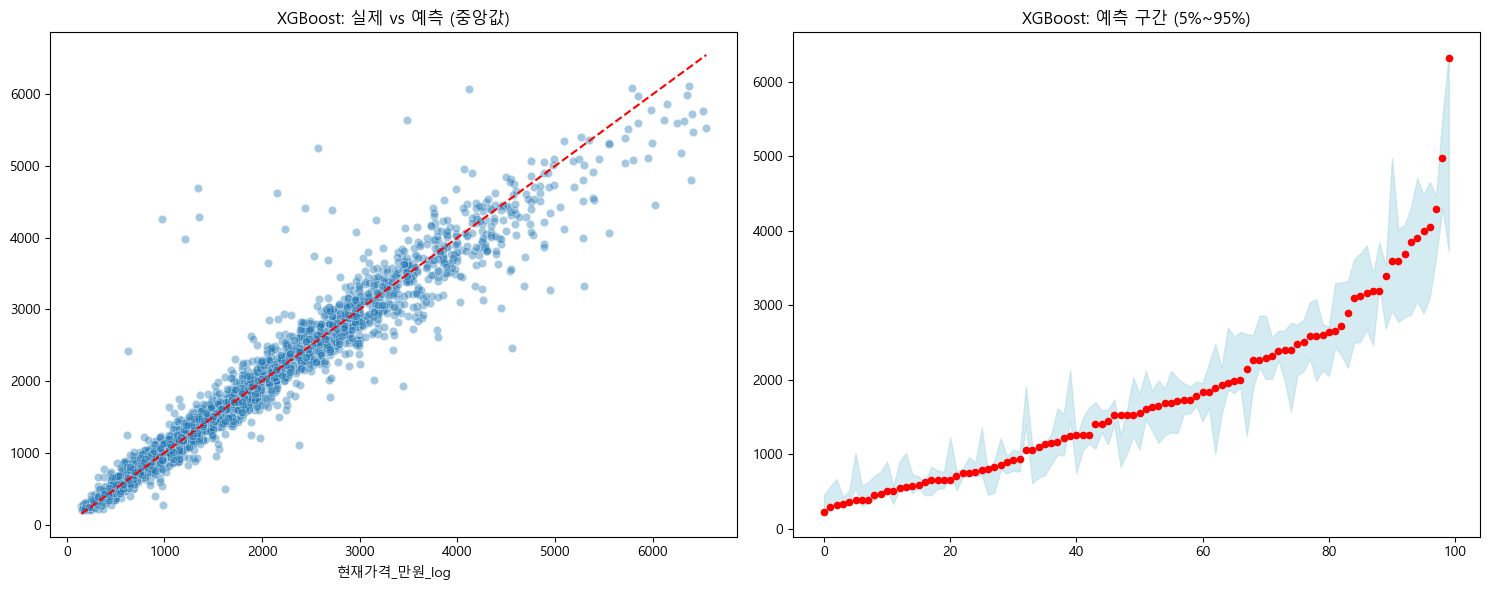

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_pinball_loss
from xgboost import XGBRegressor

# 1. 데이터 로드 및 전처리
df = pd.read_csv('./data/bermuda_data_v1_no_ev.csv')

def remove_outliers_iqr(data, column, multiplier=2.0): # multiplier=2.0 은 조금 더 비즈니스에서 lenient, outlier 제거 목적코드
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    return data[(data[column] >= Q1 - multiplier * IQR) & (data[column] <= Q3 + multiplier * IQR)]

df_clean = remove_outliers_iqr(df, '현재가격_만원')
df_clean = remove_outliers_iqr(df_clean, '주행거리_km')

# 파생 변수 및 인코딩
df_clean['연간_주행거리'] = df_clean['주행거리_km'] / (df_clean['차량연령'] + 1) # 주행거리를 보수적으로 잡아 중고차 가격책정시 정확도를 향상 
df_clean = pd.get_dummies(df_clean, columns=['모델'], drop_first=True)
df_clean = df_clean.drop(columns=['매물ID'])

# 수치형 변수 로그 변환
for col in ['현재가격_만원', '주행거리_km', '배기량_cc', '연간_주행거리', '차량연령']:
    df_clean[f'{col}_log'] = np.log1p(df_clean[col])

X = df_clean.drop(columns=['현재가격_만원', '현재가격_만원_log', '주행거리_km', '배기량_cc', '연간_주행거리', '차량연령'])
y = df_clean['현재가격_만원_log']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y_test_real = np.expm1(y_test)

# 2. XGBoost 분위수 모델 학습 (0.05, 0.5, 0.95)
quantiles = [0.05, 0.5, 0.95] # 중고차 시장 형성의 합리적 인식
models_xgb = {}

for q in quantiles: # 정밀도 향상을 위한 세팅
    xgb = XGBRegressor(
        objective='reg:quantileerror', 
        quantile_alpha=q, 
        n_estimators=800, 
        learning_rate=0.03, 
        max_depth=8, 
        subsample=0.8, 
        colsample_bytree=0.8, 
        random_state=42
    )
    xgb.fit(X_train, y_train)
    models_xgb[q] = xgb

# 3. 예측 및 지표 계산
mae = mean_absolute_error(y_test_real, preds_xgb[0.5])
rmse = np.sqrt(mean_squared_error(y_test_real, preds_xgb[0.5])) # RMSE 계산 추가
r2 = r2_score(y_test_real, preds_xgb[0.5])
coverage = np.mean((y_test_real >= preds_xgb[0.05]) & (y_test_real <= preds_xgb[0.95])) * 100
avg_width = np.mean(preds_xgb[0.95] - preds_xgb[0.05])

# 출력문 정리
print(f"=== [최종 모델 평가 지표] ===")
print(f"R^2 Score : {r2:.4f}")
print(f"RMSE      : {rmse:.2f} 만원")
print(f"MAE       : {mae:.2f} 만원")
print(f"Coverage  : {coverage:.2f} %")
print(f"Avg Width : {avg_width:.2f} 만원")

# 4. 시각화 (XGBoost 단독)
plt.rc('font', family='Malgun Gothic') # Mac은 'AppleGothic'
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 실제 vs 예측
sns.scatterplot(x=y_test_real, y=preds_xgb[0.5], alpha=0.4, ax=axes[0])
axes[0].plot([y_test_real.min(), y_test_real.max()], [y_test_real.min(), y_test_real.max()], 'r--')
axes[0].set_title("XGBoost: 실제 vs 예측 (중앙값)")

# 예측 구간 (샘플 100개)
sample_idx = np.random.choice(len(y_test_real), 100, replace=False)
sort_idx = np.argsort(y_test_real.iloc[sample_idx].values)

axes[1].fill_between(range(100), preds_xgb[0.05][sample_idx][sort_idx], 
                     preds_xgb[0.95][sample_idx][sort_idx], color='lightblue', alpha=0.5)
axes[1].scatter(range(100), y_test_real.iloc[sample_idx].values[sort_idx], color='red', s=20)
axes[1].set_title("XGBoost: 예측 구간 (5%~95%)")

plt.tight_layout()
plt.show()

In [20]:
import optuna
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor
import numpy as np

# 주의: X_train, y_train, X_test, y_test는 
# 가장 처음 166만 원이 나왔던 원본 전처리 상태의 데이터를 사용해 주세요.

def objective(trial):
    # 탐색할 하이퍼파라미터 공간 정의
    params = {
        'objective': 'reg:quantileerror',
        'quantile_alpha': 0.5,
        'n_estimators': trial.suggest_int('n_estimators', 500, 1500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 5, 12),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 7),
        'random_state': 42
    }
    
    # 모델 학습 (조기 종료 적용)
    model = XGBRegressor(**params, early_stopping_rounds=50)
    
    # 검증셋 지정하여 학습
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )
    
    # 예측 및 원래 가격(만원)으로 복원하여 MAE 계산
    preds_log = model.predict(X_test)
    preds_real = np.expm1(preds_log)
    
    mae = mean_absolute_error(y_test_real, preds_real)
    return mae

# Optuna 실행 (30번 반복 탐색)
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30)

print("\n=== Optuna 탐색 결과 ===")
print(f"최소 MAE: {study.best_value:.2f}")
print("최적 파라미터:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2026-03-18 19:14:52,510] A new study created in memory with name: no-name-38c5e8f8-8ccd-4ae8-a99a-691dc7c11ee1
[I 2026-03-18 19:14:54,540] Trial 0 finished with value: 170.3650427930643 and parameters: {'n_estimators': 659, 'learning_rate': 0.04006701997097119, 'max_depth': 12, 'subsample': 0.9876256860308541, 'colsample_bytree': 0.8698512779655094, 'min_child_weight': 6}. Best is trial 0 with value: 170.3650427930643.
[I 2026-03-18 19:14:56,221] Trial 1 finished with value: 169.72452869350673 and parameters: {'n_estimators': 1381, 'learning_rate': 0.04432032203665417, 'max_depth': 12, 'subsample': 0.8028555502731971, 'colsample_bytree': 0.9641732739125644, 'min_child_weight': 6}. Best is trial 1 with value: 169.72452869350673.
[I 2026-03-18 19:15:01,085] Trial 2 finished with value: 180.27902851097556 and parameters: {'n_estimators': 1480, 'learning_rate': 0.010438902681881876, 'max_depth': 5, 'subsample': 0.7343939124568484, 'colsample_bytree': 0.6628634179619852, 'min_child_weigh


=== Optuna 탐색 결과 ===
최소 MAE: 164.12
최적 파라미터:
  n_estimators: 1268
  learning_rate: 0.02122490173700749
  max_depth: 9
  subsample: 0.7610123756795114
  colsample_bytree: 0.6607303268397748
  min_child_weight: 3


In [21]:
! pip install category_encoders

[타겟 인코딩 + 최적화 최종 결과] MAE: 165.51 | Coverage: 82.12% | Width: 677.23


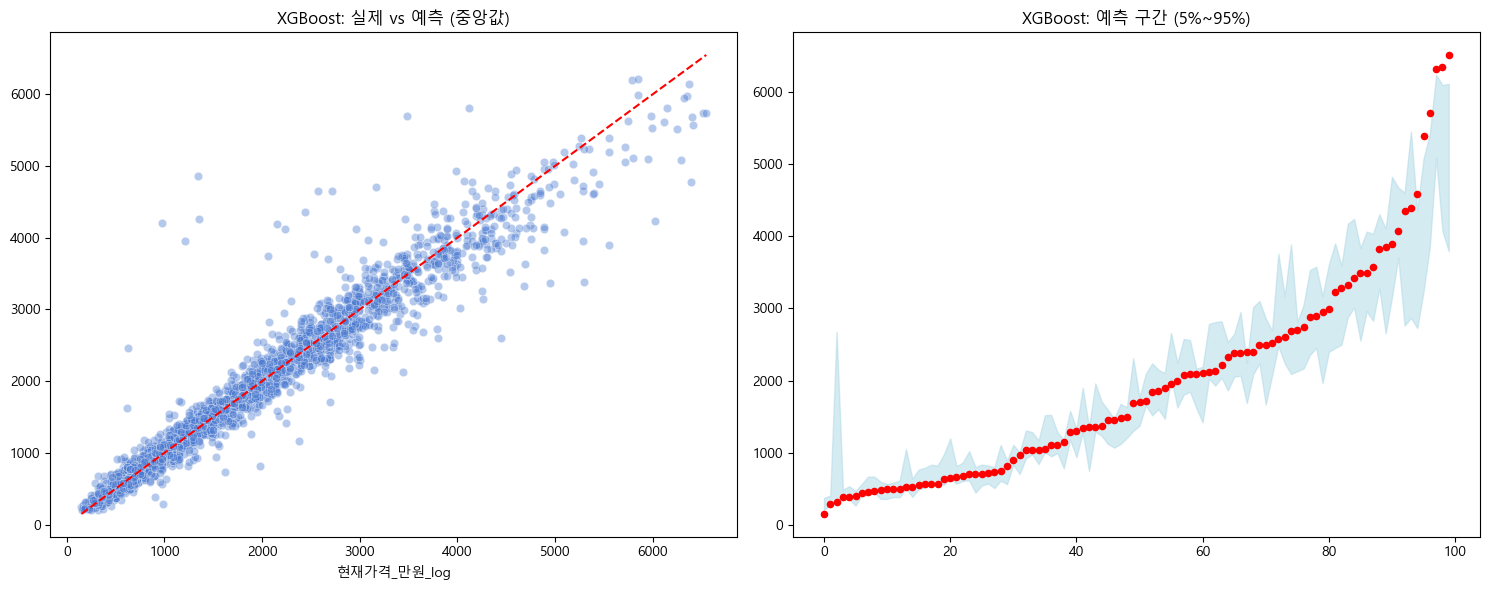

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor
import category_encoders as ce

# 1. 데이터 로드 및 이상치 제거
df = pd.read_csv('./data/bermuda_data_v1_no_ev.csv')

def remove_outliers_iqr(data, column, multiplier=2.0):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    return data[(data[column] >= Q1 - multiplier * IQR) & (data[column] <= Q3 + multiplier * IQR)]

df_clean = remove_outliers_iqr(df, '현재가격_만원')
df_clean = remove_outliers_iqr(df_clean, '주행거리_km')

# 기본 파생 변수
df_clean['연간_주행거리'] = df_clean['주행거리_km'] / (df_clean['차량연령'] + 1)
df_clean = df_clean.drop(columns=['매물ID'])

# 수치형 변수 로그 변환 (기존 컬럼 유지)
for col in ['현재가격_만원', '주행거리_km', '배기량_cc', '연간_주행거리', '차량연령']:
    df_clean[f'{col}_log'] = np.log1p(df_clean[col])

# X, y 분리 (원-핫 인코딩 pd.get_dummies 제거됨)
X = df_clean.drop(columns=['현재가격_만원', '현재가격_만원_log'])
y = df_clean['현재가격_만원_log']

# [핵심] 데이터 누수를 막기 위해 타겟 인코딩 전 Train/Test 먼저 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y_test_real = np.expm1(y_test)

# [핵심] 타겟 인코딩 적용 ('모델' 컬럼을 0, 1이 아닌 가격 평균값으로 변환)
target_encoder = ce.TargetEncoder(cols=['모델'])
# Train 셋으로만 학습(fit)하고 변환
X_train['모델_encoded'] = target_encoder.fit_transform(X_train['모델'], y_train)
# Test 셋은 Train에서 학습된 기준표를 바탕으로 변환만 수행
X_test['모델_encoded'] = target_encoder.transform(X_test['모델'])

# 학습에 불필요한 원본 '모델' 글자 컬럼 및 로그 변환 전 수치형 컬럼 일괄 제거
cols_to_drop = ['모델', '주행거리_km', '배기량_cc', '연간_주행거리', '차량연령']
X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)


# 2. XGBoost 모델 학습 (Optuna 최적 파라미터 적용)
quantiles = [0.05, 0.5, 0.95]
models_xgb = {}
preds_xgb = {}

# 찾아낸 최적 파라미터 딕셔너리
best_params = {
    'n_estimators': 1268,
    'learning_rate': 0.02122490173700749,
    'max_depth': 9,
    'subsample': 0.7610123756795114,
    'colsample_bytree': 0.6607303268397748,
    'min_child_weight': 3,
    'random_state': 42
}

for q in quantiles:
    xgb = XGBRegressor(
        objective='reg:quantileerror', 
        quantile_alpha=q, 
        **best_params,
        early_stopping_rounds=50 # 조기 종료
    )
    
    xgb.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )
    models_xgb[q] = xgb
    
    # 예측 및 원래 가격(만원)으로 복원
    preds_xgb[q] = np.expm1(xgb.predict(X_test))


# 3. 지표 계산
mae = mean_absolute_error(y_test_real, preds_xgb[0.5])
coverage = np.mean((y_test_real >= preds_xgb[0.05]) & (y_test_real <= preds_xgb[0.95])) * 100
avg_width = np.mean(preds_xgb[0.95] - preds_xgb[0.05])

print(f"[타겟 인코딩 + 최적화 최종 결과] MAE: {mae:.2f} | Coverage: {coverage:.2f}% | Width: {avg_width:.2f}")


# 4. 시각화 (XGBoost 단독)
plt.rc('font', family='Malgun Gothic') # Mac은 'AppleGothic'
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 실제 vs 예측
sns.scatterplot(x=y_test_real, y=preds_xgb[0.5], alpha=0.4, ax=axes[0])
axes[0].plot([y_test_real.min(), y_test_real.max()], [y_test_real.min(), y_test_real.max()], 'r--')
axes[0].set_title("XGBoost: 실제 vs 예측 (중앙값)")

# 예측 구간 (샘플 100개)
sample_idx = np.random.choice(len(y_test_real), 100, replace=False)
sort_idx = np.argsort(y_test_real.iloc[sample_idx].values)

axes[1].fill_between(range(100), preds_xgb[0.05][sample_idx][sort_idx], 
                     preds_xgb[0.95][sample_idx][sort_idx], color='lightblue', alpha=0.5)
axes[1].scatter(range(100), y_test_real.iloc[sample_idx].values[sort_idx], color='red', s=20)
axes[1].set_title("XGBoost: 예측 구간 (5%~95%)")

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

filepath='./data/bermuda_data_v1_no_ev.csv'
def analyze_and_suggest_encoding(file_path):
    # 1. 데이터 로드
    try:
        df = pd.read_csv(file_path)
    except Exception as e:
        return f"파일을 읽는 중 오류가 발생했습니다: {e}"

    results = []

    # 2. 각 컬럼별 분석 (수치형 제외, 범주형 데이터 위주)
    for col in df.columns:
        # 데이터 타입 확인
        dtype = df[col].dtype
        unique_count = df[col].nunique()
        sample_values = df[col].dropna().unique()[:3] # 샘플 데이터 3개
        
        # 수치형 데이터는 인코딩 대상에서 제외 (일반적으로)
        if np.issubdtype(dtype, np.number):
            continue
            
        # 판별 로직
        if unique_count == 2:
            recommendation = "Label Encoding (Binary)"
            reason = "값이 2개뿐이므로 0과 1로 변환하는 것이 가장 효율적입니다."
        elif 2 < unique_count <= 10:
            recommendation = "One-Hot Encoding"
            reason = f"고유값이 {unique_count}개로 적당하며, 모델이 값의 크기 차이를 오해하지 않도록 독립시키는 것이 좋습니다."
        else:
            recommendation = "Label Encoding"
            reason = f"고유값이 {unique_count}개로 너무 많습니다. One-Hot 사용 시 컬럼이 과도하게 늘어나 성능이 저하될 수 있습니다."

        results.append({
            '컬럼명': col,
            '데이터 타입': dtype,
            '고유값 수': unique_count,
            '샘플 데이터': list(sample_values),
            '추천 방식': recommendation,
            '이유': reason
        })

    # 결과 테이블 생성
    summary_df = pd.DataFrame(results)
    
    if summary_df.empty:
        print("분석할 범주형(문자열) 컬럼이 없습니다.")
    else:
        print("=== CSV 데이터 인코딩 추천 결과 ===\n")
        print(summary_df[['컬럼명', '고유값 수', '추천 방식', '이유']])
        print("\n" + "="*50)
        
    return df, summary_df
# --- 사용 방법 ---
# 1. 'data.csv' 부분을 본인의 파일 경로로 바꾸세요.
# df, analysis = analyze_and_suggest_encoding('your_file.csv')

NameError: name 'df' is not defined